In [8]:
#importing libraries
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [9]:
df = pd.read_csv("C:/Users/sarth/project/Final Project/data.csv")

Section 1: Dataset Understanding
1.	What is the total number of rows and columns in the dataset?
2.	What are the data types of each feature?
3.	Which features are categorical and which are numerical?
4.	Are there any missing values? If yes, in which columns?
5.	Are there any duplicate records present?


# 1. Data Understanding

In [10]:
print("No of rows: ",df.shape[0])
print("No of columns: ",df.shape[1])

No of rows:  1705
No of columns:  11


In [11]:
print("data_types: \n",df.dtypes)

data_types: 
 Student_ID                        int64
Age                               int64
Gender                           object
Academic_Level                   object
Country                          object
Avg_Daily_Usage_Hours           float64
Most_Used_Platform               object
Affects_Academic_Performance     object
Sleep_Hours_Per_Night           float64
Mental_Health_Score             float64
Overall_Impact                   object
dtype: object


In [16]:
numerical_cols = df.select_dtypes(include= ["int64","float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns
print("Numerical Columns: ",numerical_cols)
print("==="*40)
print("Categorical Columns: ",categorical_cols)

Numerical Columns:  Index(['Student_ID', 'Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score'],
      dtype='object')
Categorical Columns:  Index(['Gender', 'Academic_Level', 'Country', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Overall_Impact'],
      dtype='object')


In [18]:
#missing values 
print("Missing Values in each column: \n",df.isnull().sum())

Missing Values in each column: 
 Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Overall_Impact                  0
dtype: int64


In [22]:
print("Duplicate Rows: ",df.duplicated().sum())

Duplicate Rows:  0


#### Data is cleaned and we have done processing earlier in data_preprocessing notebook

# 3. Univariate Analysis

📈 Section 3: Univariate Analysis

10.	What is the distribution of Avg_Daily_Usage_Hours?

11.	What is the distribution of Mental_Health_Score?

12.	What is the distribution of Sleep_Hours_Per_Night?
13.	Which social media platform is most frequently used?
14.	What is the gender distribution in the dataset?


In [29]:
def distribution_plot(column):
    plt.figure(figsize=(10,6))
    sns.histplot(df[column], bins=30, kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

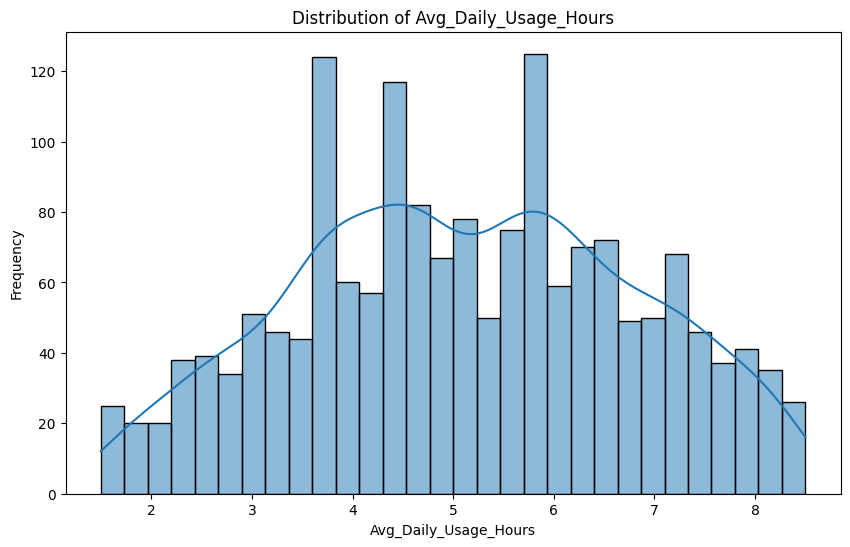

In [31]:
distribution_plot("Avg_Daily_Usage_Hours")

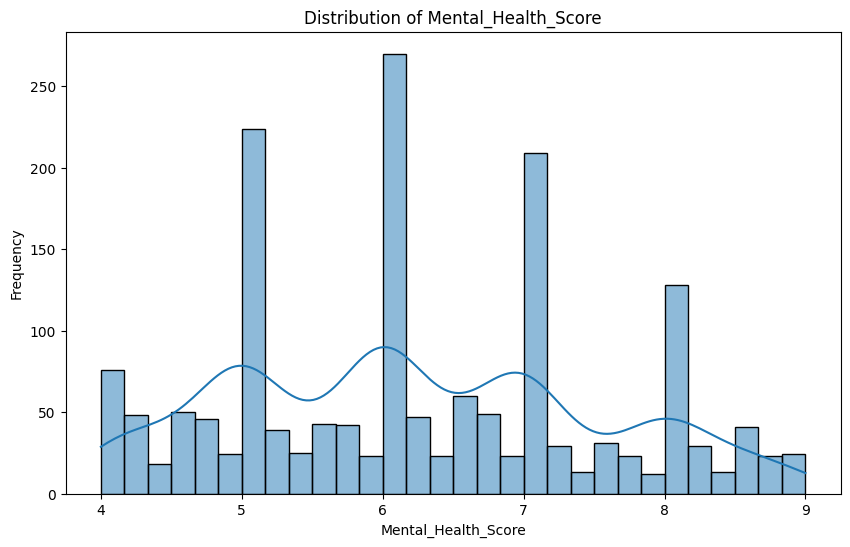

In [32]:
distribution_plot("Mental_Health_Score")

## H-1: Possibly is that those who spend more time on social media may have less mental score.

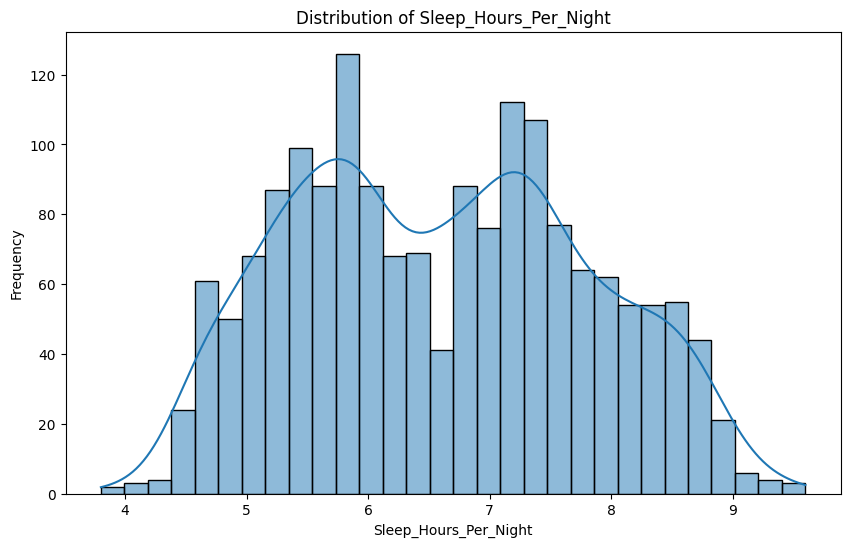

In [34]:
distribution_plot("Sleep_Hours_Per_Night")

In [36]:
# Table to understand average of each metrics
num_col = df.select_dtypes(include=['int64','float64']).columns
for i in num_col:
    print(f"Average {i}: ", df[i].mean())

Average Student_ID:  439.51026392961876
Average Age:  20.84809384164223
Average Avg_Daily_Usage_Hours:  5.103636363636364
Average Sleep_Hours_Per_Night:  6.598709677419355
Average Mental_Health_Score:  6.215131964809384


## H-2 : It is possible that people having less sleep and more social media have measure depreciation in mental health score.

In [37]:
#Most Used Platform
print("Most used platform: ",df['Most_Used_Platform'].mode()[0])

Most used platform:  Instagram


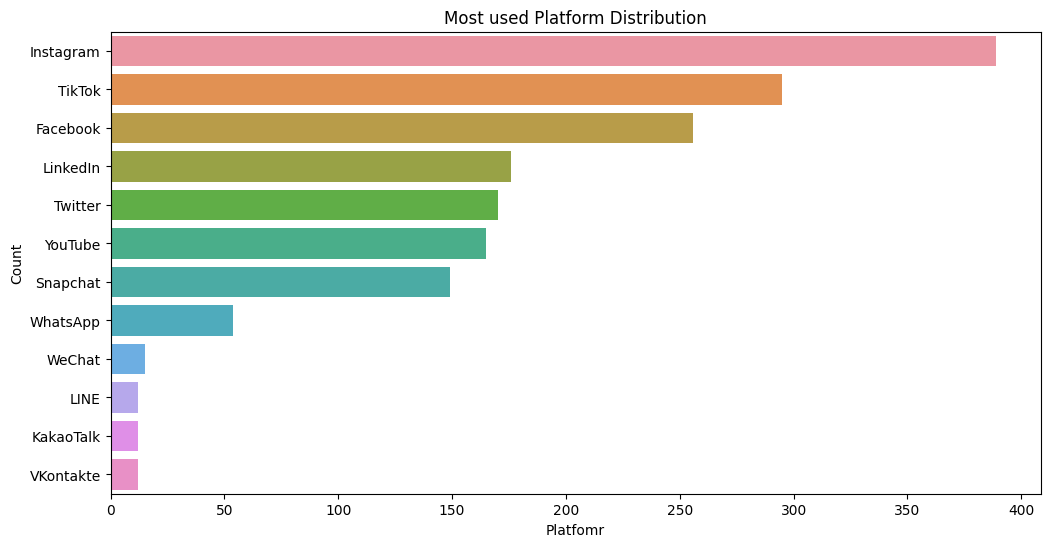

In [41]:
most = df['Most_Used_Platform'].value_counts().reset_index()
plt.figure(figsize=(12,6))
sns.barplot(x=most['Most_Used_Platform'], y=most['index'])
plt.title("Most used Platform Distribution")
plt.xlabel("Platfomr")
plt.ylabel("Count")
plt.show()

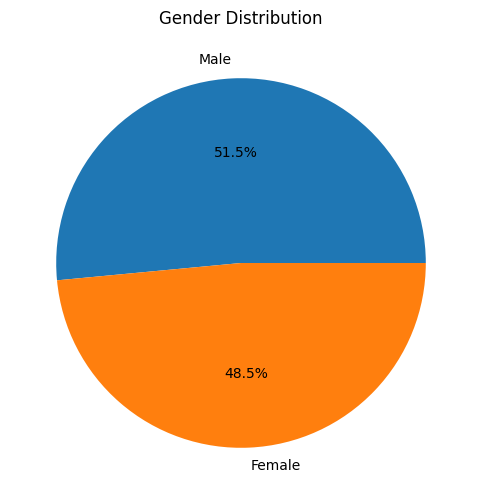

In [42]:
plt.figure(figsize=(12,6))
plt.pie(df["Gender"].value_counts(), labels= df["Gender"].value_counts().index, autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.show()

Section 4: Bivariate Analysis

15.	Is there a relationship between social media usage and mental health score?

16.	How does social media usage affect sleep duration?

17.	Do students who report academic impact have higher usage?

18.	Is there any difference in mental health scores across genders?

19.	Does age influence social media usage?


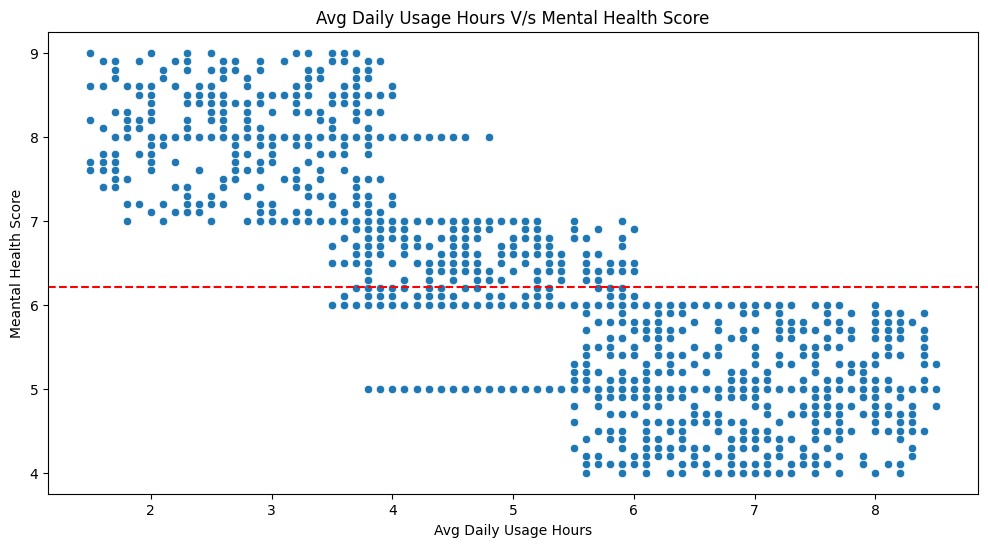

In [45]:
plt.figure(figsize=(12,6))
sns.scatterplot(x='Avg_Daily_Usage_Hours', y= 'Mental_Health_Score',data=df)
plt.axhline(y=df['Mental_Health_Score'].mean(), color='r', linestyle='--',label='Average Mental Health Score')
plt.title("Avg Daily Usage Hours V/s Mental Health Score")
plt.xlabel("Avg Daily Usage Hours")
plt.ylabel("Meantal Health Score")
plt.show()

#### There is a direct relationship between the avg_daily_usage and mental health which suggests that those who use social media more have less mental score.

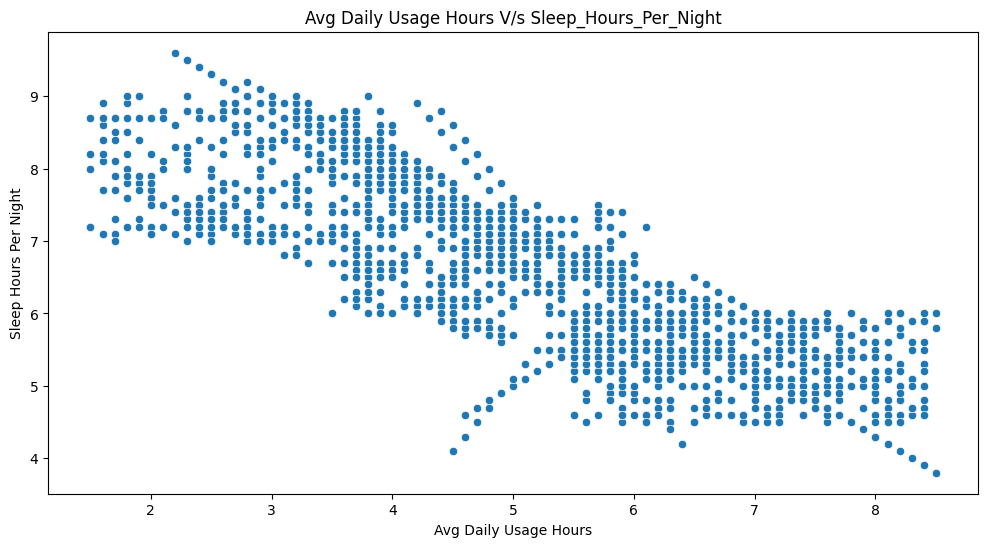

In [47]:
plt.figure(figsize=(12,6))
sns.scatterplot(x='Avg_Daily_Usage_Hours', y= 'Sleep_Hours_Per_Night',data=df)
plt.title("Avg Daily Usage Hours V/s Sleep_Hours_Per_Night")
plt.xlabel("Avg Daily Usage Hours")
plt.ylabel("Sleep Hours Per Night")
plt.show()

#### There is a direct relationship between the avg_daily_usage and sleep_hours which suggests that those who use social media more have less sleep.

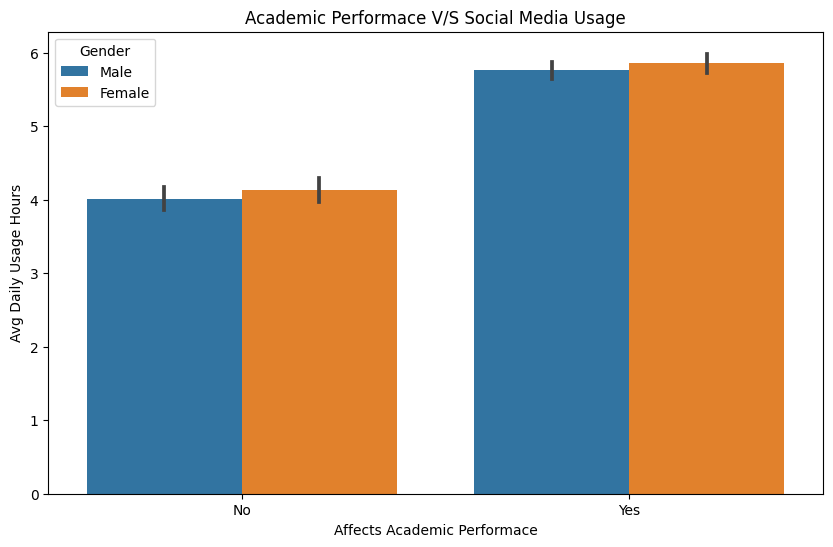

In [49]:
plt.figure(figsize=(10,6))
sns.barplot(x = "Affects_Academic_Performance", y = "Avg_Daily_Usage_Hours", data = df, hue='Gender')
plt.title("Academic Performace V/S Social Media Usage")
plt.xlabel("Affects Academic Performace")
plt.ylabel("Avg Daily Usage Hours")
plt.show()


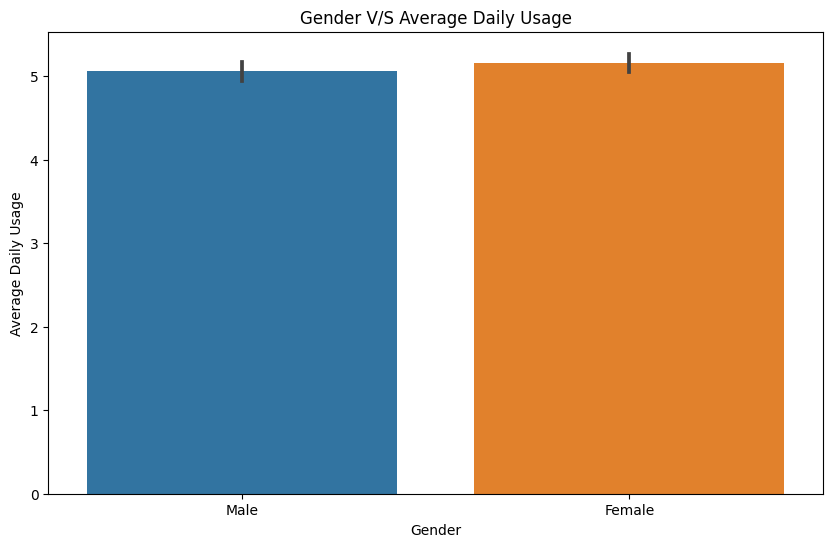

In [53]:
plt.figure(figsize=(10,6))
sns.barplot(x = "Gender", y = "Avg_Daily_Usage_Hours", data = df)
plt.title("Gender V/S Average Daily Usage")
plt.xlabel("Gender")
plt.ylabel("Average Daily Usage")
plt.show()


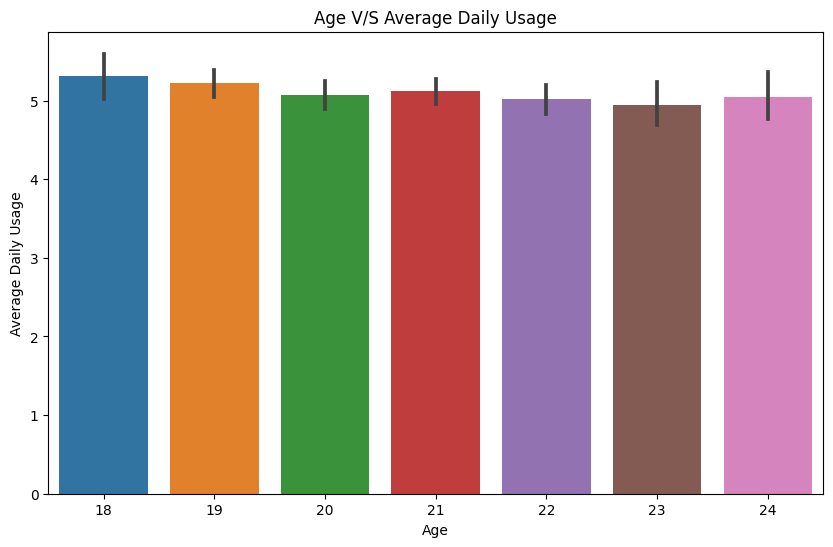

In [54]:
plt.figure(figsize=(10,6))
sns.barplot(x = "Age", y = "Avg_Daily_Usage_Hours", data = df)
plt.title("Age V/S Average Daily Usage")
plt.xlabel("Age")
plt.ylabel("Average Daily Usage")
plt.show()


📊 Section 5: Categorical Insights

20.	Which platform is associated with the highest negative impact?

21.	How does Overall_Impact (Positive/Neutral/Negative) vary across platforms?

22.	Which gender reports more negative impact?

23.	Which academic level is most affected by social media?


In [55]:
df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Overall_Impact
0,232,21,Male,Undergraduate,Other,4.0,Facebook,No,6.7,6.8,Neutral
1,564,23,Female,Undergraduate,Other,1.6,LinkedIn,No,8.6,7.6,Positive
2,788,22,Male,Graduate,Canada,4.6,Instagram,No,6.7,7.0,Neutral
3,686,18,Male,Undergraduate,Other,7.0,Snapchat,Yes,5.4,5.3,Negative
4,608,24,Female,High School,Other,7.5,Facebook,Yes,5.0,4.4,Negative


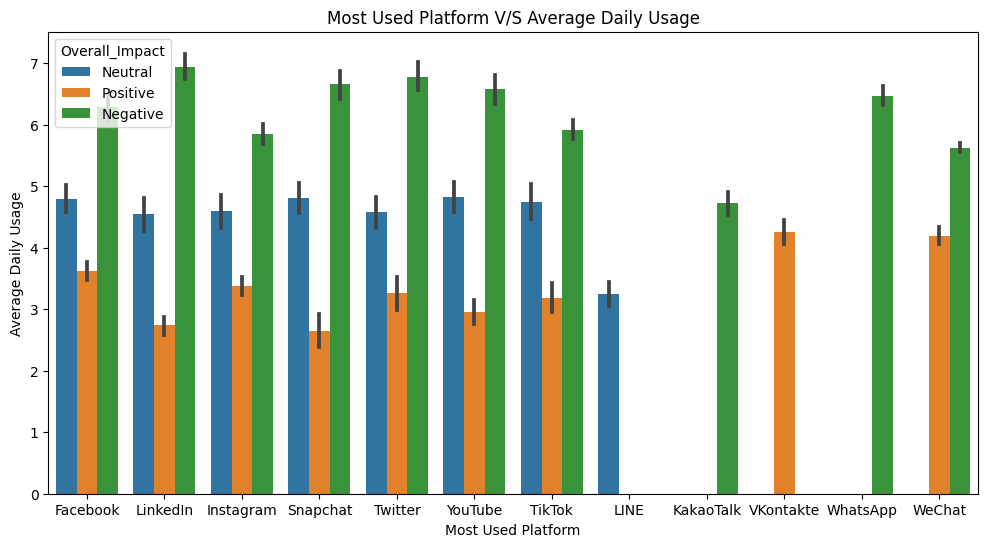

In [64]:
plt.figure(figsize=(12,6))
sns.barplot(x = "Most_Used_Platform", y = "Avg_Daily_Usage_Hours", data = df,hue='Overall_Impact')
plt.title("Most Used Platform V/S Average Daily Usage")
plt.xlabel("Most Used Platform")
plt.ylabel("Average Daily Usage")
plt.show()


### From above observation the most used platform with highest negative impact is linkedin. Overall most of the platforms have negative impace except VKontakte which has positive impact and LINE which has neutral impact rest all the platforms have higher negative impact

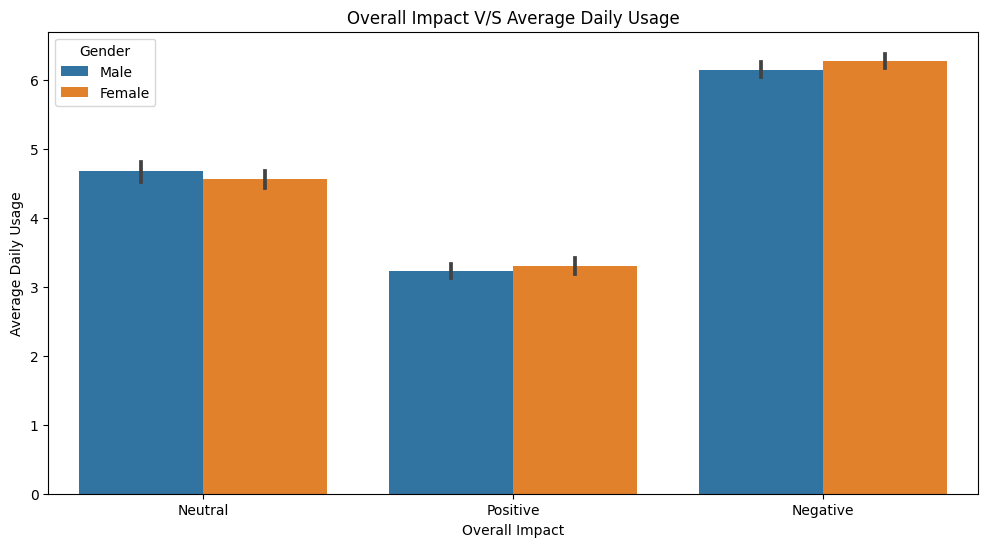

In [77]:
plt.figure(figsize=(12,6))
sns.barplot(x = "Overall_Impact", y = "Avg_Daily_Usage_Hours", data = df,hue='Gender')
plt.title("Overall Impact V/S Average Daily Usage")
plt.xlabel("Overall Impact")
plt.ylabel("Average Daily Usage")
plt.show()


#### Female Gender has overall more Negative Impact but the difference is not that significant in this case

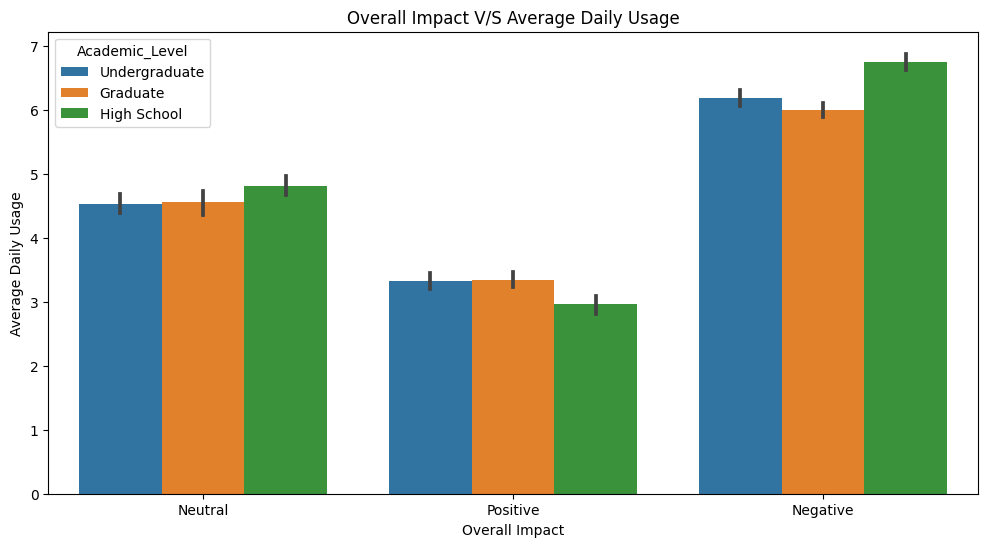

In [78]:
plt.figure(figsize=(12,6))
sns.barplot(x = "Overall_Impact", y = "Avg_Daily_Usage_Hours", data = df,hue='Academic_Level')
plt.title("Overall Impact V/S Average Daily Usage")
plt.xlabel("Overall Impact")
plt.ylabel("Average Daily Usage")
plt.show()


### Highest Negative Impact of Social Media is on High School going Academic Level and Undergraduates after that

🧪 Section 6: Correlation & Pattern Analysis

24.	What is the correlation between:

•	Usage hours & mental health

•	Usage hours & sleep

•	Sleep & mental health


25.	Which variables show strong correlations?

26.	Are there any unexpected patterns or anomalies?


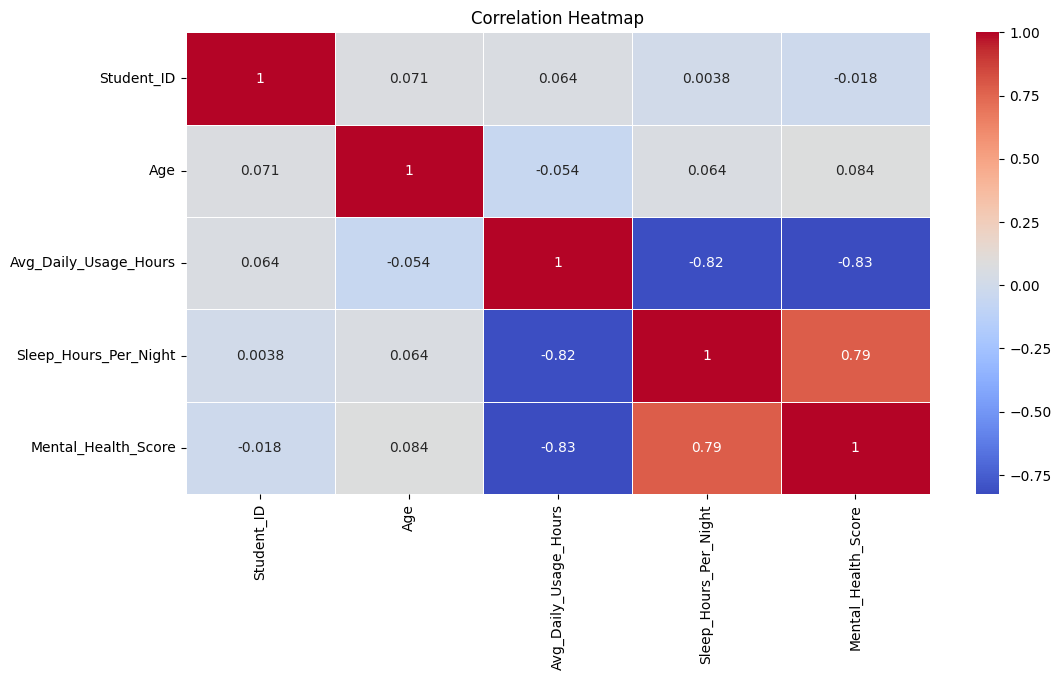

In [79]:
# Correlation
plt.figure(figsize=(12,6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(),annot=True, cmap='coolwarm',linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

### Average Daily Usage Hours and Mental health are negatively correlated(0.82)
### Average Daily Usage Hours and Sleep are also negatively correlated(0.83)
### Sleep and Mental Health are postively correlated(0.79)

### Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score are strongly correalted

### There are no unexpected patterns or anomalies